In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv("dataset/train.csv")

In [3]:
colmns = data.columns.to_list()
colmns.remove('label')

In [4]:
# Pull out the pixel columns and scale values to the 0-1 range so gradients behave better.
features = data[colmns].to_numpy() / 255
# Keep the raw digit labels around before we split anything.
labels = data['label'].to_numpy()

# Shuffle the rows once so the split is random but still reproducible.
rng = np.random.default_rng(150)
indices = rng.permutation(len(features))
# Use an 80/20 split: most examples for learning, the rest for honest evaluation.
split_index = int(0.8 * len(features))
train_indices = indices[:split_index]
test_indices = indices[split_index:]

# Build the two datasets from the shuffled row indices.
train_data = features[train_indices]
test_data = features[test_indices]
# Split the labels alongside the images so they stay aligned.
train_label = labels[train_indices]
test_label = labels[test_indices]

In [5]:
# Convert class numbers into one-hot vectors for softmax training.
y_train = np.eye(10)[train_label]
test_labels = np.eye(10)[test_label]

In [6]:
# Quick sanity check so we know the split sizes and label shapes are correct.
print(f"train_data shape: {train_data.shape}")
print(f"test_data shape: {test_data.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"test_labels shape: {test_labels.shape}")

train_data shape: (33600, 784)
test_data shape: (8400, 784)
y_train shape: (33600, 10)
test_labels shape: (8400, 10)


In [7]:
# Fix the random seed so weight initialization stays reproducible while experimenting.
np.random.seed(150)
# The initialization helps ReLU layers start with activations that do not vanish too quickly.
def hidden_layer(input_dim, output_dim):
    if output_dim != None:
        return np.random.randn(input_dim, output_dim) * np.sqrt(2/input_dim)
    else:
        return np.zeros(input_dim)

# Raised when we try to use the network before calling make().
class ModelNotReady(Exception):
    """Error raised when model isnt built"""
    pass

# Raised when the input width does not match what the network expects.
class InvalidInputSize(Exception):
    """Error raised when input size is incomplete"""
    pass

# A simple feed-forward neural network built from scratch with NumPy.
class model:

    def __init__(self,num_layers,input_size,output_size,hidden_layer_size=[]):
        # Save the architecture so the rest of the class knows what to build.
        self.num_layers = num_layers
        self.input_size = input_size
        self.model = []
        self.hidden_layer_size = hidden_layer_size
        self.output_size = output_size
        self.bias = []
        self.layers = []
        self.model = []
        # These lists keep the forward-pass values needed for backpropagation.
        self.activation_values = []
        self.z_values = []
        
    def make(self):
        # The hidden_layer_size list defines how many neurons each hidden layer has.
        if len(self.hidden_layer_size) != self.num_layers:
            print("error making the model")
            return None
        # Build each layer one by one from input to output.
        for i in range(self.num_layers):
            # The first matrix connects the input pixels to the first hidden layer.
            if i ==0:
                self.layers.append(hidden_layer(self.input_size,self.hidden_layer_size[i]))
                self.bias.append(hidden_layer(self.hidden_layer_size[i],None))

            # Each internal layer connects one hidden block to the next hidden block.
            if i+1 < self.num_layers:
                matrix_shape = (self.hidden_layer_size[i],self.hidden_layer_size[i+1])
                bias_shape = self.hidden_layer_size[i+1]

            # The final layer maps the last hidden representation to digit scores.
            else:
                matrix_shape = (self.hidden_layer_size[i],self.output_size)
                bias_shape = self.output_size
            
            # Create the weight matrix for this layer.
            self.layers.append(hidden_layer(*matrix_shape))
            # Create the matching bias vector if this layer needs one.
            if bias_shape != None:
                bias_layer = hidden_layer(bias_shape,None)
                self.bias.append(bias_layer)
            
        # Store each weight/bias pair together so backprop can update them in place.
        for layer,bias in zip(self.layers,self.bias):
            self.model.append([layer,bias])
        # Return the finished network.
        return self.model
    
    # ReLU keeps positive signals and kills negative ones, which helps deep networks learn faster.
    def activation(self,matrix,function="relu"):
        if function ==  "relu":
            return np.maximum(0,matrix)
        elif function == "sigmoid":
            return 1/(1+np.exp(matrix))

    # Backprop needs the slope of the activation function at each stored pre-activation value.
    def activation_derivative(self, matrix, function="relu"):
        if function == "relu":
            return np.where(matrix > 0, 1, 0)
        elif function == "sigmoid":
            return 1/(1+np.exp(-matrix))

    # Forward pass means: multiply by weights, add bias, then apply activation.
    def forward_pass(self,input):
        # Clear old cached values so each batch starts fresh.
        self.activation_values = []
        self.z_values = []
        
        # Start the network from the incoming input batch.
        self.a = input
        if self.model == []:
            raise ModelNotReady("Please make the model first.")
        # Each row must contain the same number of features the model was built for.
        if not input.shape[1] == self.input_size:
            raise InvalidInputSize("the size of the input doesnt math the model's input architecture.")
        
        # Save the input as activation zero, because backprop works layer by layer backward.
        self.activation_values.append(self.a)
        
        # Run through every layer in order.
        for layer_num,layer in enumerate(self.model):
            # Z = A * W + b
            self.z = np.dot(self.a,layer[0]) + layer[1]
            self.z_values.append(self.z)

            # Hidden layers use ReLU here so the network can build nonlinear features.
            if not layer_num +1 == len(self.model) :
                self.a = self.activation(self.z)
                self.activation_values.append(self.a)
            else:
                # The final layer uses softmax so outputs become class probabilities.
                exp_z = np.exp(self.z - np.max(self.z, axis=1, keepdims=True)) # e^(z-max(z))
                self.a = exp_z / np.sum(exp_z, axis=1, keepdims=True)
                self.activation_values.append(self.a)

        # Return the predicted probabilities for each class.
        return self.a
    
    # Cross-entropy tells us how far the predicted probability distribution is from the true one-hot label.
    def compute_loss(self, y_pred, y_true):
        epsilon = 1e-9
        # Clip probabilities so log() never sees a zero.
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        
        loss = -np.sum(y_true * np.log(y_pred)) / y_true.shape[0]
        return loss
    
    # Backpropagation sends the error backward and nudges weights in the direction that lowers loss.
    def backward(self, y_pred, y_true, learning_rate=0.01):
        # m is the batch size, used to keep gradient updates scale-independent.
        m = y_true.shape[0] if len(y_true.shape) > 0 else 1
        
        # For softmax + cross-entropy, the gradient at the output is simply prediction minus truth.
        dz = (y_pred - y_true) / m
        
        # Walk backward through the network one layer at a time.
        for i in reversed(range(len(self.model))):
            # Activation from the layer before this one is what fed into the current weights.
            a_prev = self.activation_values[i]
            
            # dW is the average contribution of each input feature to each output neuron.
            dw = np.dot(a_prev.T, dz)
            # db is the total error signal each neuron received across the batch.
            db = np.sum(dz, axis=0)
            
            # If this is not the first layer, pass the error one step further back.
            if i > 0:
                da = np.dot(dz, self.model[i][0].T)
                # ReLU derivative gates the gradient so only active neurons backpropagate signal.
                dz = da * self.activation_derivative(self.z_values[i-1])

            # Gradient descent: subtract a small step of the gradient from weights and bias.
            self.model[i][0] -= learning_rate * dw
            self.model[i][1] -= learning_rate * db

    # Accuracy here means: did the model assign the highest probability to the correct digit?
    def validate(self, y_true, y_pred, metric="accuracy", thresh=.3):
        assert(len(y_pred)==len(y_true))
        
        # Compare the predicted class index with the true class index.
        correct = np.sum(np.argmax(y_pred, axis=1) == np.argmax(y_true, axis=1))
        
        return (correct/len(y_pred))*100

# Creating a sample neural network below
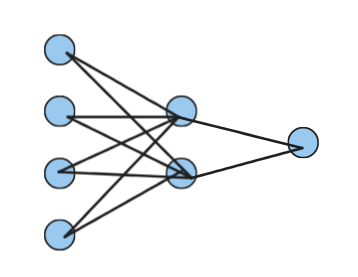

In [8]:
# This tiny example is just a sanity check for the class wiring.
# It has 4 input features, one hidden layer with 2 neurons, and one output.
np.random.seed(150)

model_from_scratch = model(1,4,1,[2])
m=model_from_scratch.make()
# Create a handful of fake samples so we can test the forward pass quickly.
num_samples = 15
input_size = model_from_scratch.input_size
input = np.random.rand(num_samples,input_size)

In [9]:
# Run the toy example through the network to make sure shapes line up.
model_from_scratch.forward_pass(input)

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

In [10]:
# Build the actual MNIST classifier: 784 inputs for pixels and 10 output classes.
m = model(1,784,10,[128])
m.make()
print("created the neural network")

created the neural network


In [11]:
# Run one forward pass on the training split to confirm the network outputs class probabilities.
m.forward_pass(train_data)

array([[0.19688879, 0.09045523, 0.03225435, ..., 0.0557854 , 0.09594458,
        0.08539146],
       [0.11679057, 0.22397173, 0.07183282, ..., 0.05793085, 0.06616271,
        0.05265171],
       [0.13952625, 0.08847149, 0.0834358 , ..., 0.06098126, 0.09624058,
        0.08784214],
       ...,
       [0.080343  , 0.09960171, 0.11316935, ..., 0.08204549, 0.10251151,
        0.08810814],
       [0.16194697, 0.07407811, 0.03079186, ..., 0.02855733, 0.10505429,
        0.07985546],
       [0.22009858, 0.09801937, 0.06886143, ..., 0.08257998, 0.08659603,
        0.08551442]], shape=(33600, 10))

In [12]:
# The loss tells us how wrong the current predictions are before any training step.
m.compute_loss(m.forward_pass(train_data),np.array(y_train))

np.float64(2.455378482175961)

# Training Loop

In [13]:
# Train for a fixed number of passes over the training data.
num_epochs= 100
# Learning rate controls how large each gradient step is.
learning_rate = .1
for i in range(num_epochs):
    # First do a forward pass so we know what the current network predicts.
    y_pred = m.forward_pass(train_data)
    # Convert labels to a NumPy array because backprop expects array math.
    y_true = np.array(y_train)
    # Push the error backward and update weights in place.
    m.backward(y_pred, y_true,learning_rate=learning_rate)

    # Print training progress so we can see whether the model is improving.
    print(f"epoch {i+1} complete. accuracy: {m.validate(y_true, y_pred):.2f}%")
    

epoch 1 complete. accuracy: 9.16%
epoch 2 complete. accuracy: 14.52%
epoch 3 complete. accuracy: 21.38%
epoch 4 complete. accuracy: 29.24%
epoch 5 complete. accuracy: 37.26%
epoch 6 complete. accuracy: 45.16%
epoch 7 complete. accuracy: 52.01%
epoch 8 complete. accuracy: 57.25%
epoch 9 complete. accuracy: 61.22%
epoch 10 complete. accuracy: 64.20%
epoch 11 complete. accuracy: 66.65%
epoch 12 complete. accuracy: 68.81%
epoch 13 complete. accuracy: 70.36%
epoch 14 complete. accuracy: 71.72%
epoch 15 complete. accuracy: 73.01%
epoch 16 complete. accuracy: 74.07%
epoch 17 complete. accuracy: 74.99%
epoch 18 complete. accuracy: 75.80%
epoch 19 complete. accuracy: 76.49%
epoch 20 complete. accuracy: 77.15%
epoch 21 complete. accuracy: 77.68%
epoch 22 complete. accuracy: 78.21%
epoch 23 complete. accuracy: 78.64%
epoch 24 complete. accuracy: 79.10%
epoch 25 complete. accuracy: 79.48%
epoch 26 complete. accuracy: 79.90%
epoch 27 complete. accuracy: 80.27%
epoch 28 complete. accuracy: 80.62%
ep

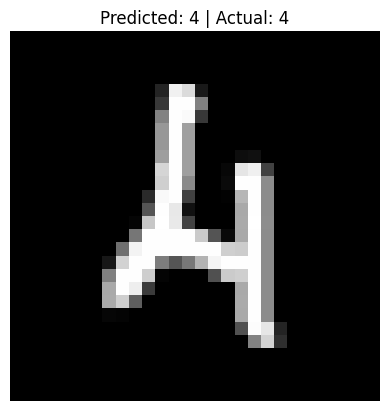

In [ ]:
# Pick one random held-out example to see the model's prediction visually.
import numpy as np
import matplotlib.pyplot as plt

# Choose one image from the test set, not the training set.
random_index = np.random.randint(0, len(test_data))

# Pull out the image and its true one-hot label.
image = test_data[random_index]
true_label = np.argmax(test_labels[random_index])

# Reshape to one row because the network expects a batch dimension.
input_image = image.reshape(1, 784)

# Run the image through the trained network.
predictions = m.forward_pass(input_image)

# The highest probability becomes the predicted digit.
predicted_label = np.argmax(predictions)

# Show the image and save a copy so the result is easy to inspect later.
plt.imshow(image.reshape(28, 28), cmap='gray')

plt.title(f"Predicted: {predicted_label} | Actual: {true_label}")
plt.axis('off')
plt.show()